In [ ]:
%pip install ultralytics

In [1]:
# Import required libraries
import os
import shutil
import random
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("All libraries imported successfully!")
print(f"\nPackage versions:")
print(f"- OpenCV: {cv2.__version__}")
print(f"- NumPy: {np.__version__}")
print(f"- Pandas: {pd.__version__}")

# Check ultralytics version
import ultralytics
print(f"- Ultralytics: {ultralytics.__version__}")
print("\n✓ Ready for YOLOv11 Large training!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All libraries imported successfully!

Package versions:
- OpenCV: 4.12.0
- NumPy: 2.2.6
- Pandas: 2.3.3
- Ultralytics: 8.3.227

✓ Ready for YOLOv11 Large training!


In [21]:
# Load YOLOv11 Large pre-trained model
model_name = 'yolo11l.pt'  # YOLOv11 Large

print("=" * 70)
print(f"Loading YOLOv11 Large model: {model_name}")
print("=" * 70)

model = YOLO(model_name)

print(f"\n✓ YOLOv11 Large loaded successfully!")
print(f"  Model type: {type(model)}")
print(f"\nYOLOv11 Large Features:")
print("  • Enhanced architecture for maximum accuracy")
print("  • Superior feature extraction capabilities")
print("  • Optimized for complex detection tasks")
print("  • Best performance for medical imaging applications")
print("\n✓ Ready for finetuning on malaria cell detection!")

Loading YOLOv11 Large model: yolo11l.pt

✓ YOLOv11 Large loaded successfully!
  Model type: <class 'ultralytics.models.yolo.model.YOLO'>

YOLOv11 Large Features:
  • Enhanced architecture for maximum accuracy
  • Superior feature extraction capabilities
  • Optimized for complex detection tasks
  • Best performance for medical imaging applications

✓ Ready for finetuning on malaria cell detection!


In [23]:
# Training hyperparameters optimized for YOLOv11 Large with enhanced overlap handling
training_params = {
    'data': str("/kaggle/input/boundingboxyolo/dataset/data.yaml"),
    'epochs': 100,
    'imgsz': 640,
    'batch': 8,
    'patience': 10,
    'save': True,
    'save_period': 10,
    'project': str("/kaggle/working/"),
    'name': 'yolo11_large_malaria3',
    'exist_ok': True,
    'pretrained': True,
    'optimizer': 'AdamW',
    'lr0': 0.0005,
    'lrf': 0.001,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 5,
    'warmup_momentum': 0.8,
    'warmup_bias_lr': 0.1,
    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    
    # KEY AUGMENTATIONS FOR OVERLAPPING OBJECTS
    'mosaic': 1.0,
    'mixup': 0.1, 
    'copy_paste': 0.3,                      
    'iou': 0.5, 
    'conf': 0.25,
    'max_det': 300,
    
    'amp': True,
    'fraction': 1.0,
    'profile': False,
    'freeze': None,
    'multi_scale': False,
    'overlap_mask': True,
    'mask_ratio': 4,
    'dropout': 0.0,
    'val': True,
    'plots': True,
    'verbose': True,
    'device': 0,
}

In [24]:
results = model.train(**training_params)

Ultralytics 8.3.227 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/boundingboxyolo/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.5, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11_large_malaria3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pa

In [25]:
# Load the best trained model 
best_model_path = "/kaggle/working/yolo11_large_malaria3/weights/best.pt" 
print(f"Loading best YOLOv11 Large model from: {best_model_path}") 

best_model = YOLO(str(best_model_path))
print("✓ Best model loaded successfully!")

# Run validation on test set
print("\n" + "=" * 70)
print("RUNNING VALIDATION ON TEST SET")
print("=" * 70)

val_results = best_model.val(data=str("/kaggle/input/boundingboxyolo/dataset/data.yaml"), split='val')

# Extract comprehensive metrics
metrics = val_results.results_dict
precision = metrics.get('metrics/precision(B)', 0)
recall = metrics.get('metrics/recall(B)', 0)
mAP50 = metrics.get('metrics/mAP50(B)', 0)
mAP50_95 = metrics.get('metrics/mAP50-95(B)', 0)

# Calculate F1 Score
if precision + recall > 0:
    f1_score_val = 2 * (precision * recall) / (precision + recall)
else:
    f1_score_val = 0

print("\n" + "=" * 70)
print("YOLOv11 LARGE - PERFORMANCE METRICS")
print("=" * 70)
print(f"Precision:        {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:           {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:         {f1_score_val:.4f} ({f1_score_val*100:.2f}%)")
print(f"mAP@0.5:          {mAP50:.4f} ({mAP50*100:.2f}%)")
print(f"mAP@0.5:0.95:     {mAP50_95:.4f} ({mAP50_95*100:.2f}%)")
print("=" * 70)

Loading best YOLOv11 Large model from: /kaggle/working/yolo11_large_malaria3/weights/best.pt
✓ Best model loaded successfully!

RUNNING VALIDATION ON TEST SET
Ultralytics 8.3.227 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11l summary (fused): 190 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1425.5±1252.0 MB/s, size: 1961.1 KB)
val: Scanning /kaggle/input/boundingboxyolo/dataset/labels/val... 299 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 299/299 664.6it/s 0.4s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/boundingboxyolo/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.0it/s 18.1s0.5s
                   all        299      36719      0.942      0.976       0.98      0.888
Speed: 2.5ms preprocess, 29.2ms inference, 0.0ms loss, 5.0ms postprocess per image
Results sa

Running YOLOv11 Large inference on 8 test images...


NameError: name 'RESULTS_DIR' is not defined

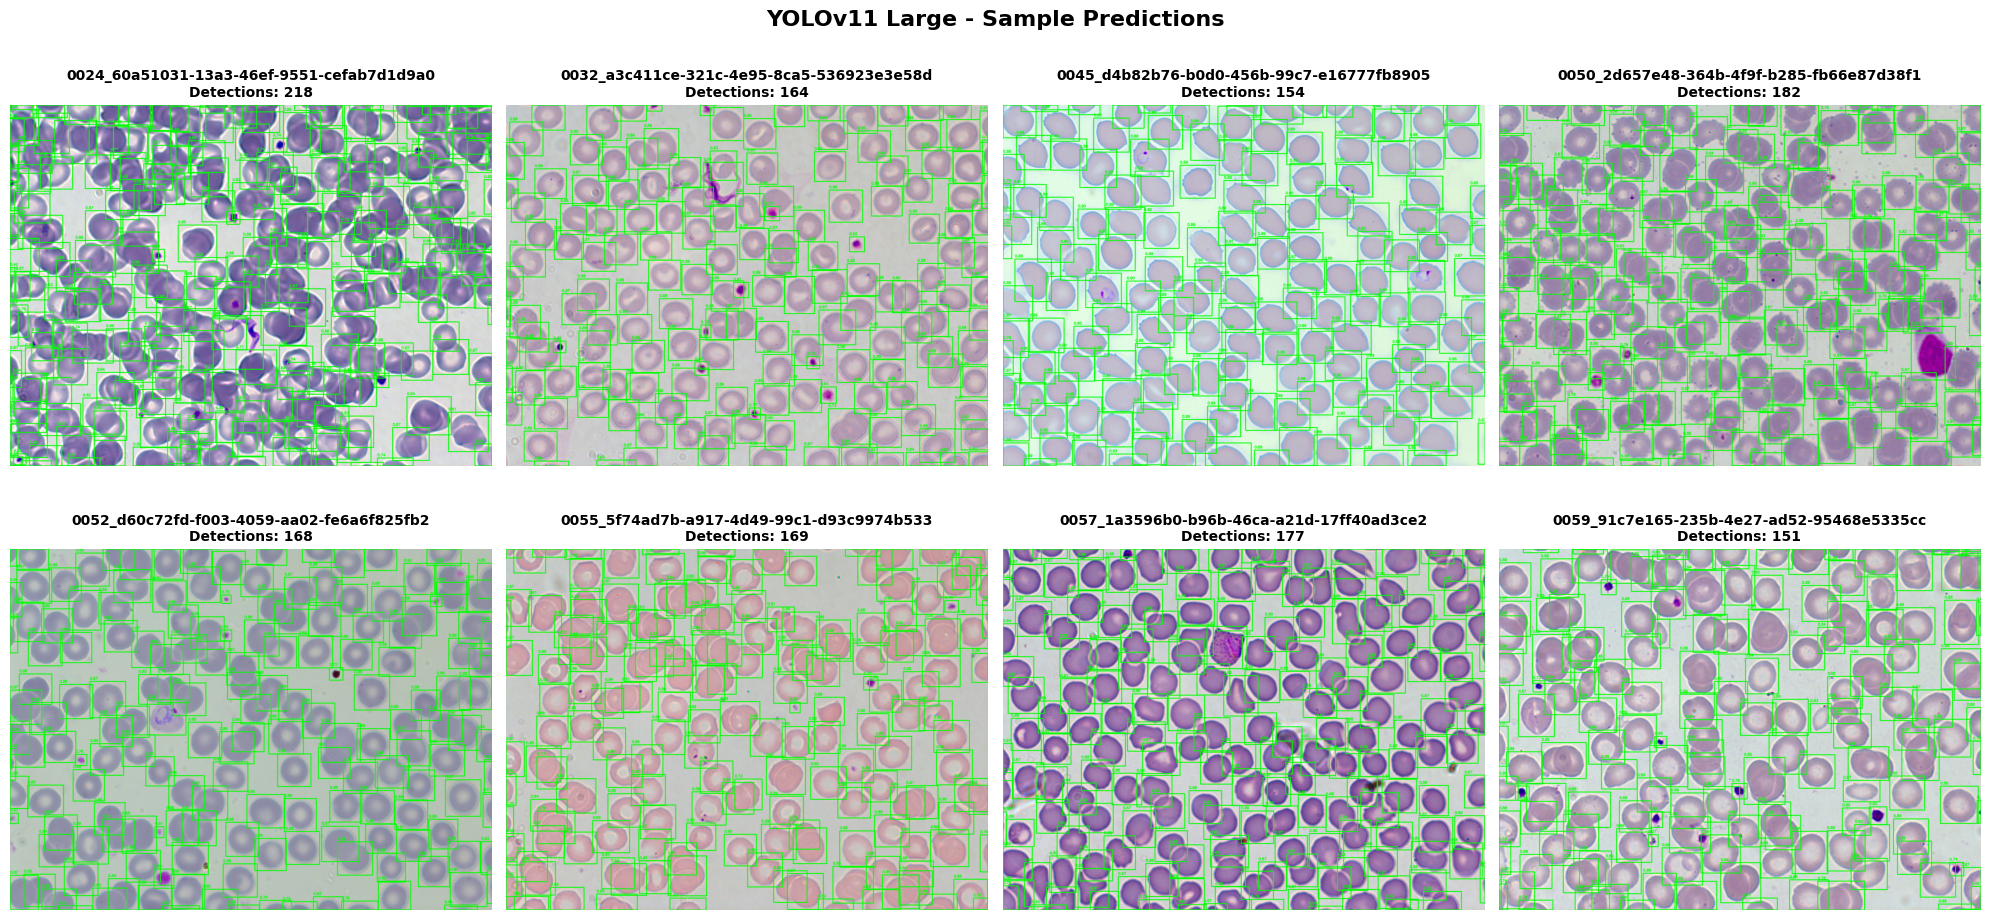

In [28]:
from pathlib import Path

# Run predictions on sample test images
val_images_dir = Path("/kaggle/input/boundingboxyolo/dataset/images/val")
test_images = sorted(list(val_images_dir.glob("*")))[:8]

print(f"Running YOLOv11 Large inference on {len(test_images)} test images...")

predictions = best_model.predict(
    source=[str(img) for img in test_images],
    conf=0.25,
    iou=0.45,
    save=False,
    verbose=False
)

# Visualize predictions
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (img_path, pred) in enumerate(zip(test_images, predictions)):
    if idx >= 8:
        break
    
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    if pred.boxes is not None and len(pred.boxes) > 0:
        for box in pred.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = box.conf[0].cpu().numpy()
            
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
            label = f'{conf:.2f}'
            cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 
                       0.6, (0, 255, 0), 2)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f'{img_path.stem}\nDetections: {len(pred.boxes) if pred.boxes is not None else 0}',
                       fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('YOLOv11 Large - Sample Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('yolo11_large_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Sample predictions saved to: {'yolo11_large_predictions.png'}")